In [1]:
import sys
from pyprojroot import here

# Ritorna il percorso assoluto della root del progetto
PROJECT_ROOT = str(here()) + "/"
sys.path.append(PROJECT_ROOT)

print(f"La root del progetto è: {PROJECT_ROOT}")

La root del progetto è: /home/cvalentino/SissaUnisaDraftCodes/


In [2]:
from paths import INV_PATH, TP2_PATH

ABS_PATH = PROJECT_ROOT + INV_PATH + TP2_PATH
LOAD_MSH = PROJECT_ROOT

model_name = "column"
xdmf_file_name = "column.xdmf"

# Nome figure
fig_dir = "figures/"
eig_fig = ABS_PATH + fig_dir + "sv.png"
error_fig = ABS_PATH + fig_dir + "error.png"
speed_up_fig = ABS_PATH + fig_dir + "speed_up.png"
samples_fig = ABS_PATH + fig_dir + "samples.png"

dbdir = ABS_PATH + "database/"

In [3]:
import fenics as fe

from fem_problems.invTP2.finite_element import SystemParabolicFEM
from fem_problems.invTP2.rbnics_pod_temp import TemporalPOD

[michael-Alienware-Aurora-R15:11037] shmem: mmap: an error occurred while determining whether or not /tmp/ompi.michael-Alienware-Aurora-R15.1001/jf.0/725942272/shared_mem_cuda_pool.michael-Alienware-Aurora-R15 could be created.
[michael-Alienware-Aurora-R15:11037] create_and_attach: unable to create shared memory BTL coordinating structure :: size 134217728 


Carichiamo la mesh

In [4]:
# Path to the XDMF file
file_path = ABS_PATH + xdmf_file_name

# Carica la mesh da file XDMF
mesh = fe.Mesh()
with fe.XDMFFile(file_path) as infile:
    infile.read(mesh)

Definiamo il range dei parametri

In [5]:
mu_range = [
    (0, 1.),
    (0, 1.),
    (0, 1.),
]

Definiamo il problema fem e il pod

In [6]:
temporal_steps = 21
time_interval = [0, 1]

fem_p = SystemParabolicFEM(mesh, time_interval, temporal_steps)
pod = TemporalPOD(mu_range, fem_p)

In [7]:
num_training = 20
num_testing = 5

N_modes = num_training*fem_p.temp_points
tol = 1e-6

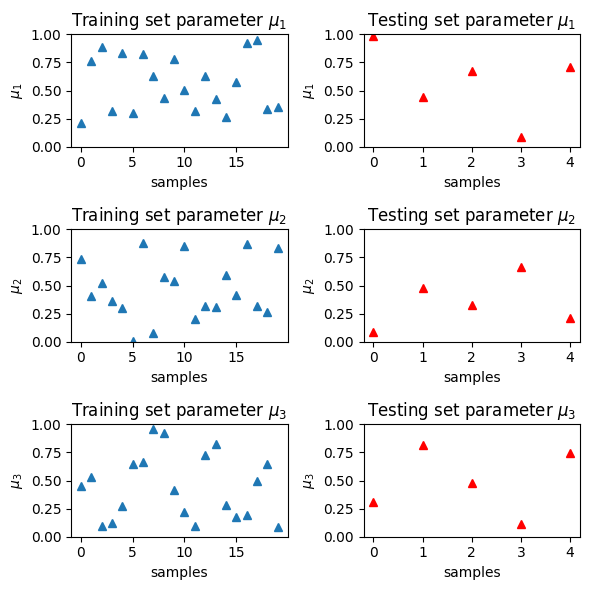

In [8]:
training = pod.sampling_parameters(num_training)
testing = pod.sampling_parameters(num_testing, test=True)
pod.plot_samples(figsize = (6, 6), filename=samples_fig)

In [9]:
pod.pod_execution(N_modes, tol)

STORING SNAPSHOTS...
+++ Compute and store temporal snaphot 1 for mu = [0.21006932 0.73965599 0.45085418] +++
STORING TEMPORAL SNAPSHOT
... End of compute and store temporal snaphot 1
+++ Compute and store temporal snaphot 2 for mu = [0.76686518 0.40644375 0.52919413] +++
STORING TEMPORAL SNAPSHOT
... End of compute and store temporal snaphot 2
+++ Compute and store temporal snaphot 3 for mu = [0.89041319 0.52256584 0.09569638] +++
STORING TEMPORAL SNAPSHOT
... End of compute and store temporal snaphot 3
+++ Compute and store temporal snaphot 4 for mu = [0.32202448 0.35841192 0.12388586] +++
STORING TEMPORAL SNAPSHOT
... End of compute and store temporal snaphot 4
+++ Compute and store temporal snaphot 5 for mu = [0.83348276 0.29874761 0.2777842 ] +++
STORING TEMPORAL SNAPSHOT
... End of compute and store temporal snaphot 5
+++ Compute and store temporal snaphot 6 for mu = [0.30224813 0.00810525 0.64455079] +++
STORING TEMPORAL SNAPSHOT
... End of compute and store temporal snaphot 6
+

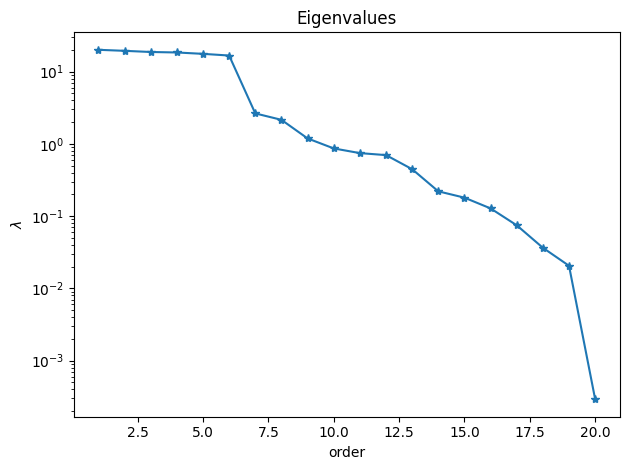

In [10]:
pod.plot_eigenvalues(filename=eig_fig)

In [11]:
pod.store_reduction(directory=dbdir, filename=model_name)

Start STORING REDUCTION......End STORING REDUCTION


In [12]:
mu_test = [.2, .6, .4]
mat, _ = pod.solve_rom(mu_test, pod.num_basis)
fom_m, _ = pod.fem_p.solve_fem(mu_test)
real_m, _ = pod.fem_p.exact_solution(mu_test)

print("ERRORE FOM-ESATTA")
e, f = pod.fem_p.compute_error(fom_m, real_m)
print("ERRORE ROM-FOM")
a, b = pod.fem_p.compute_error(mat, fom_m)
print("ERRORE ROM-ESATTA")
c, d = pod.fem_p.compute_error(mat, real_m)

ERRORE FOM-ESATTA
ERRORI EQUAZIONE 1
Errore Assoluto: 8.0557e-01
Errore Relativo: 1.7018e-02
ERRORI EQUAZIONE 2
Errore Assoluto: 8.1097e-01
Errore Relativo: 1.1281e-02
ERRORE ROM-FOM
ERRORI EQUAZIONE 1
Errore Assoluto: 8.0739e-03
Errore Relativo: 1.7061e-04
ERRORI EQUAZIONE 2
Errore Assoluto: 7.5953e-03
Errore Relativo: 1.0573e-04
ERRORE ROM-ESATTA
ERRORI EQUAZIONE 1
Errore Assoluto: 8.0506e-01
Errore Relativo: 1.7007e-02
ERRORI EQUAZIONE 2
Errore Assoluto: 8.0609e-01
Errore Relativo: 1.1213e-02


In [13]:
error, _ = pod.error_analysis()


=============== POD basis number N = 1 ===============
Solve for test parameter i = 0, mu=[0.98817446 0.08850452 0.30902745]
Solve for test parameter i = 1, mu=[0.44529873 0.47681199 0.81352625]
Solve for test parameter i = 2, mu=[0.67657305 0.32520107 0.48047766]
Solve for test parameter i = 3, mu=[0.08262213 0.6607373  0.11734811]
Solve for test parameter i = 4, mu=[0.70770543 0.21041175 0.74922193]

=============== POD basis number N = 2 ===============
Solve for test parameter i = 0, mu=[0.98817446 0.08850452 0.30902745]
Solve for test parameter i = 1, mu=[0.44529873 0.47681199 0.81352625]
Solve for test parameter i = 2, mu=[0.67657305 0.32520107 0.48047766]
Solve for test parameter i = 3, mu=[0.08262213 0.6607373  0.11734811]
Solve for test parameter i = 4, mu=[0.70770543 0.21041175 0.74922193]

=============== POD basis number N = 3 ===============
Solve for test parameter i = 0, mu=[0.98817446 0.08850452 0.30902745]
Solve for test parameter i = 1, mu=[0.44529873 0.47681199 0.81

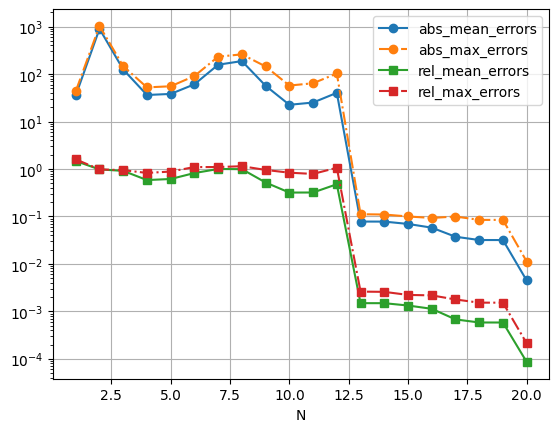

In [14]:
pod.plot_errors(error, filename=error_fig)

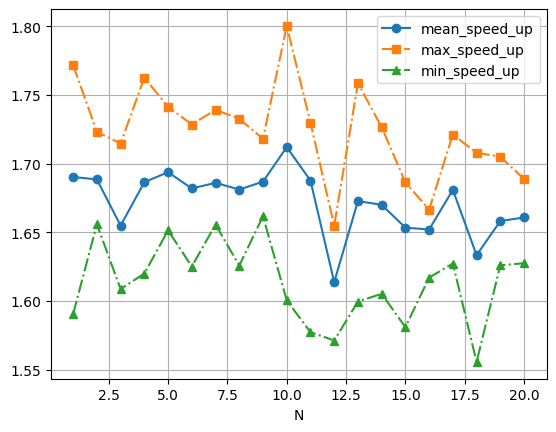

In [ ]:
pod.plot_speed_up(error, filename=speed_up_fig)

In [16]:
pod.save_table_error(error)

In [17]:
pod.table_error(error)

Solution errors:
+-----+-----------------+----------------+--------------------------+-------------------------+------------+
|   N |   mean(error_u) |   max(error_u) |   mean(relative_error_u) |   max(relative_error_u) |   speed_up |
+=====+=================+================+==========================+=========================+============+
|   1 |     35.4758     |     43.3762    |              1.46641     |             1.59472     |    1.69034 |
+-----+-----------------+----------------+--------------------------+-------------------------+------------+
|   2 |    895.798      |   1032.36      |              0.978814    |             0.980705    |    1.68857 |
+-----+-----------------+----------------+--------------------------+-------------------------+------------+
|   3 |    124.52       |    146.232     |              0.911426    |             0.94221     |    1.65491 |
+-----+-----------------+----------------+--------------------------+-------------------------+------------+
| 